In [3]:
import os, sys
from pathlib import Path

# Run from the project3 root so `src` imports and the relative data/ paths resolve
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import study_table, findings_texts, usable_findings, binary_label
from src.embeddings import embedding_path, load_embeddings
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import umap
import umap
%matplotlib inline

studies = study_table()
X = load_embeddings(embedding_path("findings"), studies)   # shape (10000, 768)

print(X)

[[ 0.18298799 -0.44056645  0.09515159 ...  0.07182322  0.05536532
  -0.06340577]
 [ 0.10669665 -0.30799073  0.06032721 ...  0.13065429  0.04378948
  -0.05930331]
 [ 0.03643291 -0.24765347  0.00449395 ...  0.3761811  -0.10992087
  -0.12382317]
 ...
 [ 0.02697561 -0.14964852  0.02131842 ...  0.181169    0.1840704
  -0.10840277]
 [ 0.15912485 -0.20432124  0.08101012 ...  0.07829165  0.10553113
  -0.03475408]
 [ 0.3450488  -0.2522628  -0.06874678 ...  0.11079008  0.3010458
  -0.05515804]]


In [4]:
# Make the picture with the default (15) and with one small and one large value, for example 5 and 200. 
# Colour the points by the edema and pleural effusion labels (clear cases only, the rest grey), then by metadata: health system, manufacturer, age, year, report length. Do the groups you see follow the diseases, or something else?

sns.set_theme(style='white', context='notebook', rc={'figure.figsize':(14,10)})

In [5]:
mask = usable_findings(studies).values
Xu, su = X[mask], studies[mask].reset_index(drop=True) # filtering X and studies to only usable findings

def plot_labels(obs, n_neighbors):
    embedding = umap.UMAP(n_neighbors=n_neighbors, random_state=42).fit_transform(Xu)
    y = binary_label(su, obs)
    palette = {0.0: sns.color_palette()[0], 1.0: sns.color_palette()[3]}
    colors = [palette.get(v, (0.8, 0.8, 0.8)) for v in y]   # NaN -> grey
    plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=3)
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection, {obs} (n_neighbors={n_neighbors})', fontsize=24)
    plt.show()
    

/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


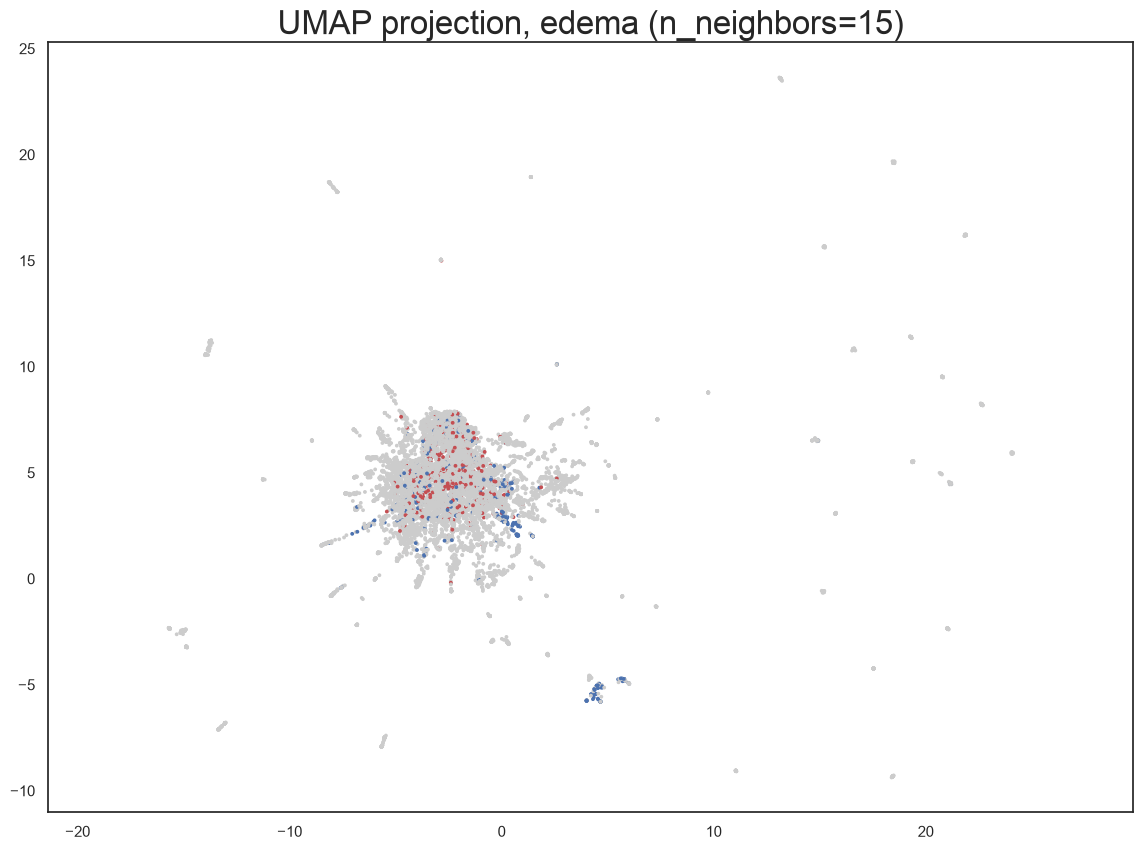

/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


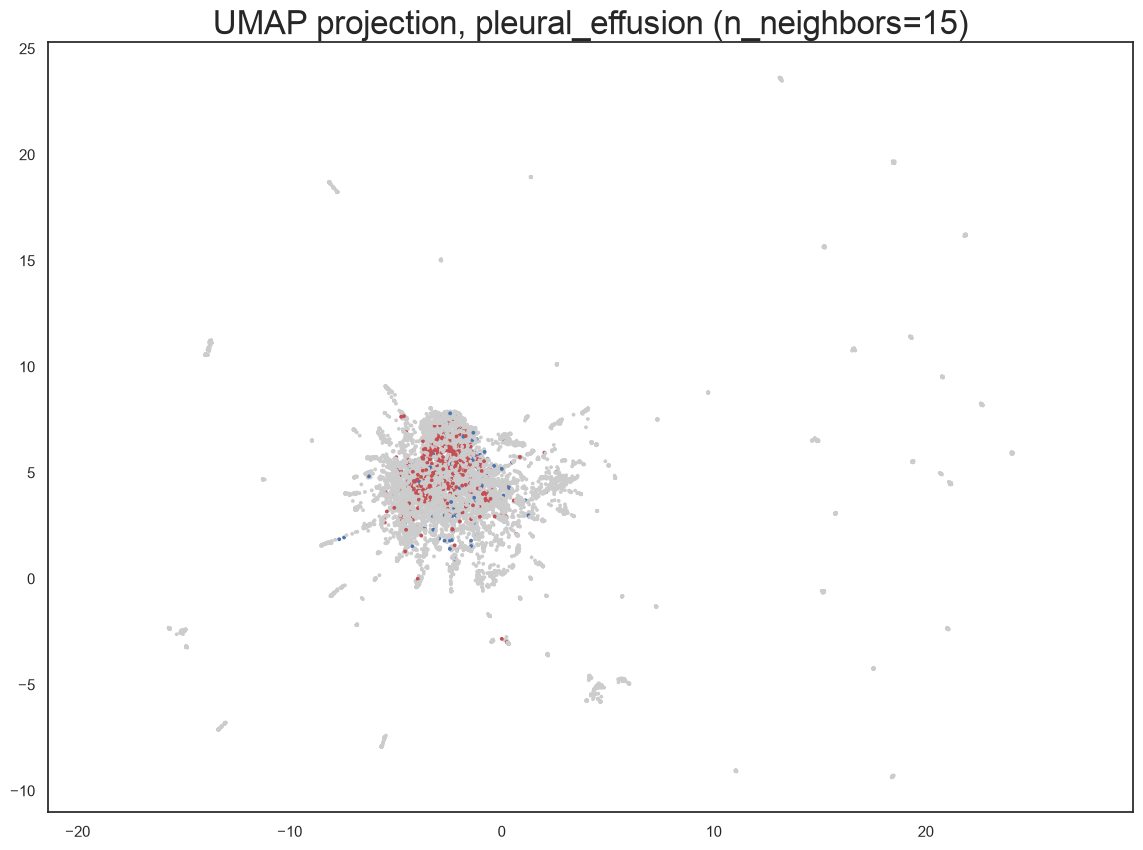

In [6]:
n_neighbours = 15
plot_labels("edema", n_neighbours)
plot_labels("pleural_effusion", n_neighbours)


/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/um

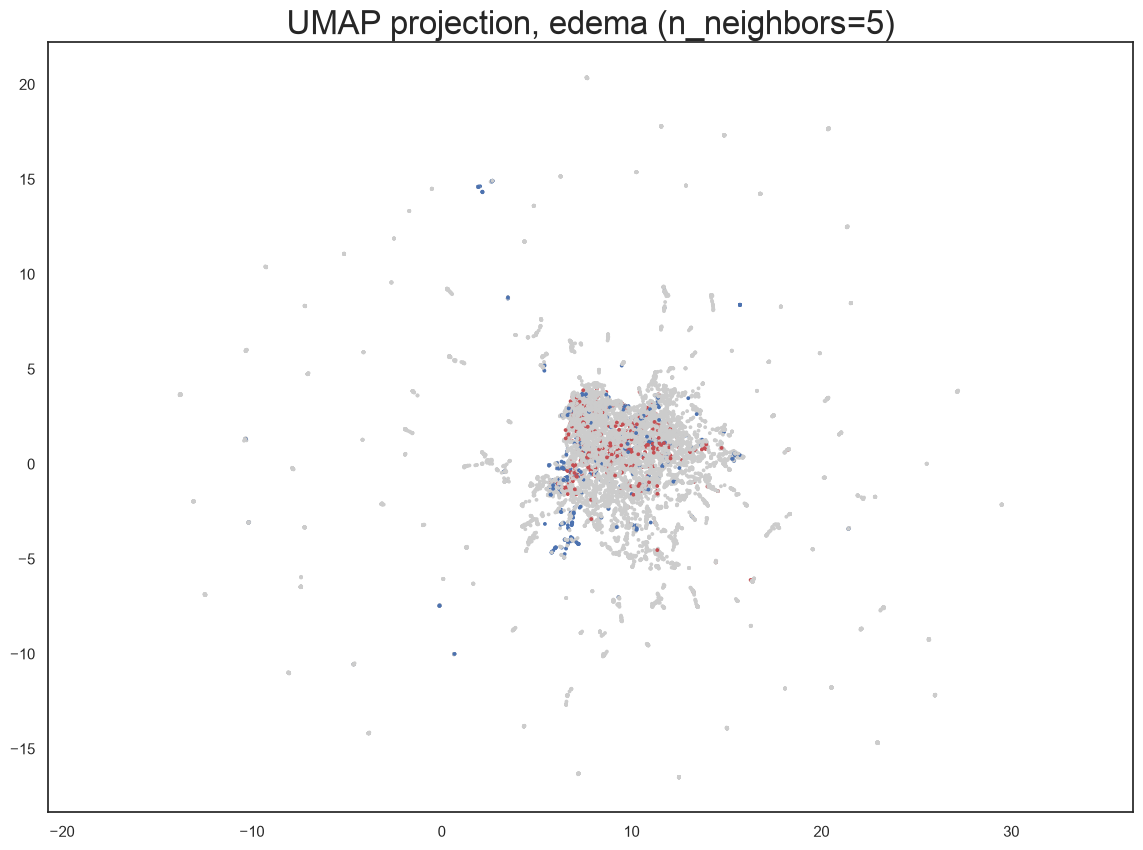

/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/um

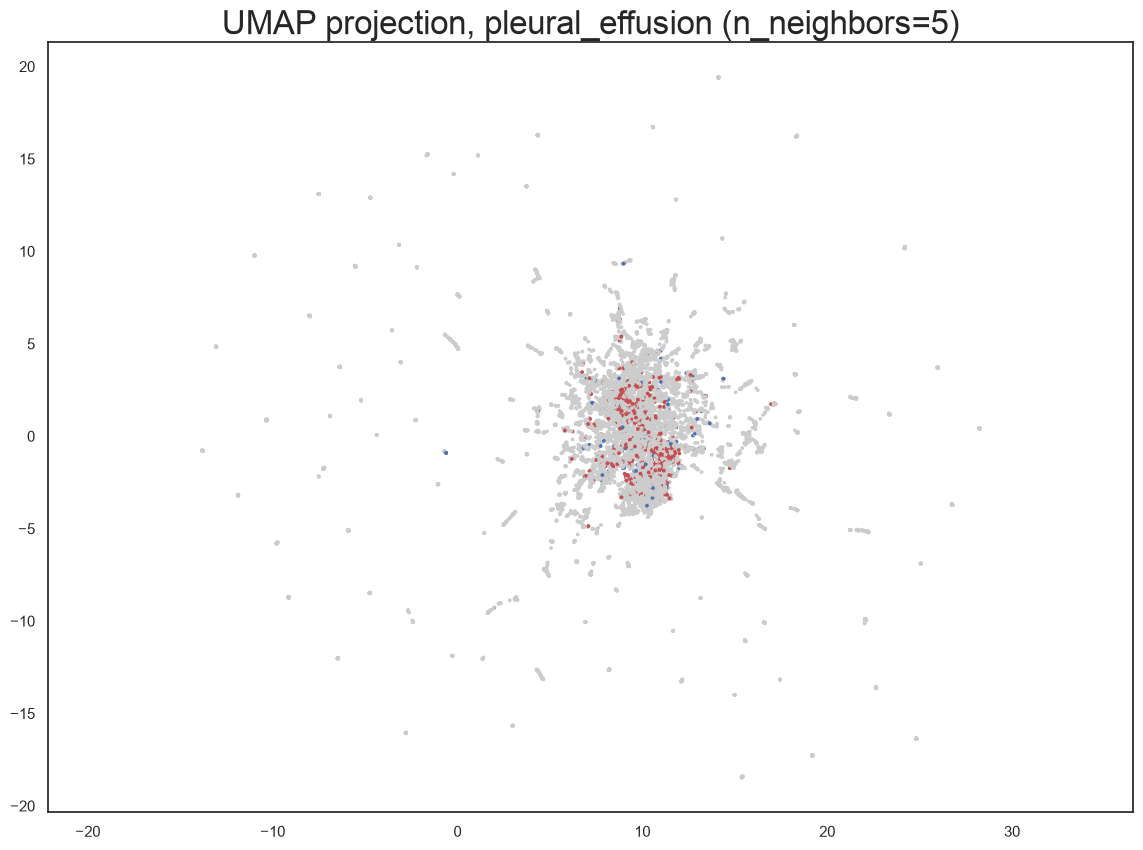

In [7]:
n_neighbours = 5
plot_labels("edema", n_neighbours)
plot_labels("pleural_effusion", n_neighbours)
plt.show()

/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


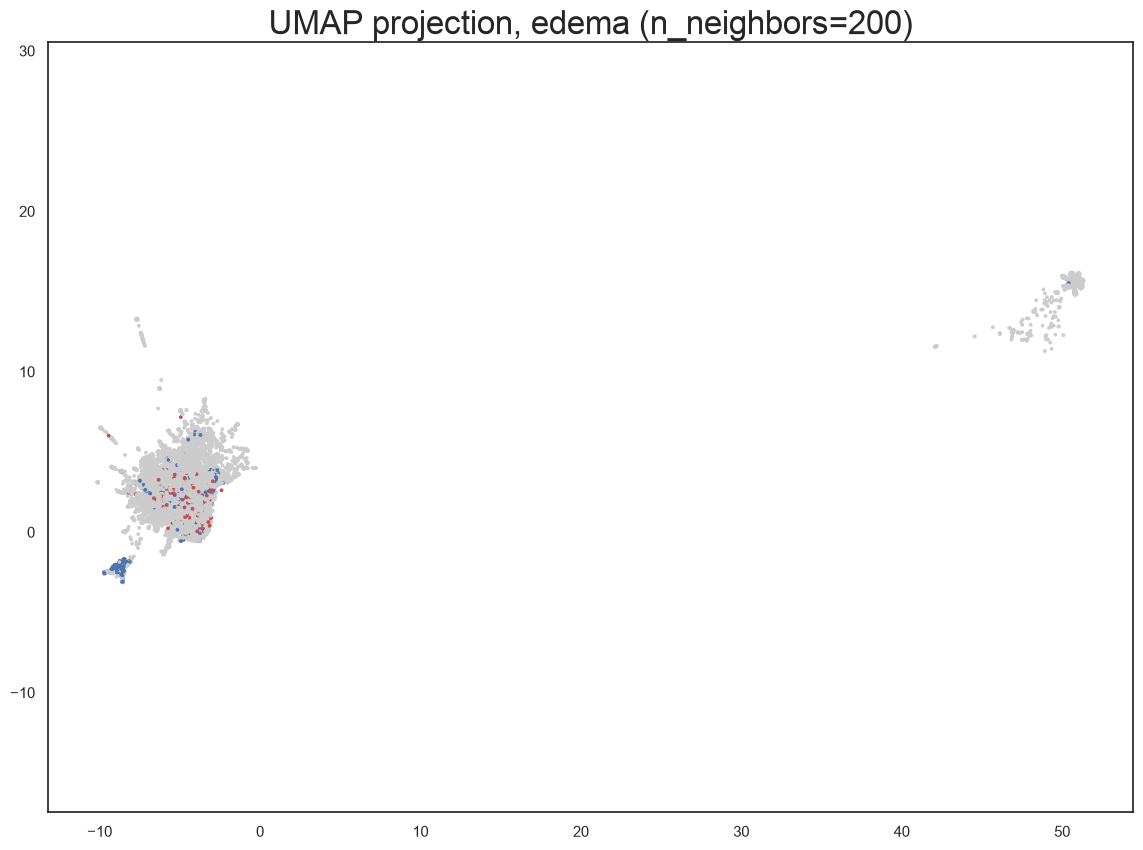

/Users/ritasantos/Documents/DTU/Fall2026/02517/Responsible_AI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


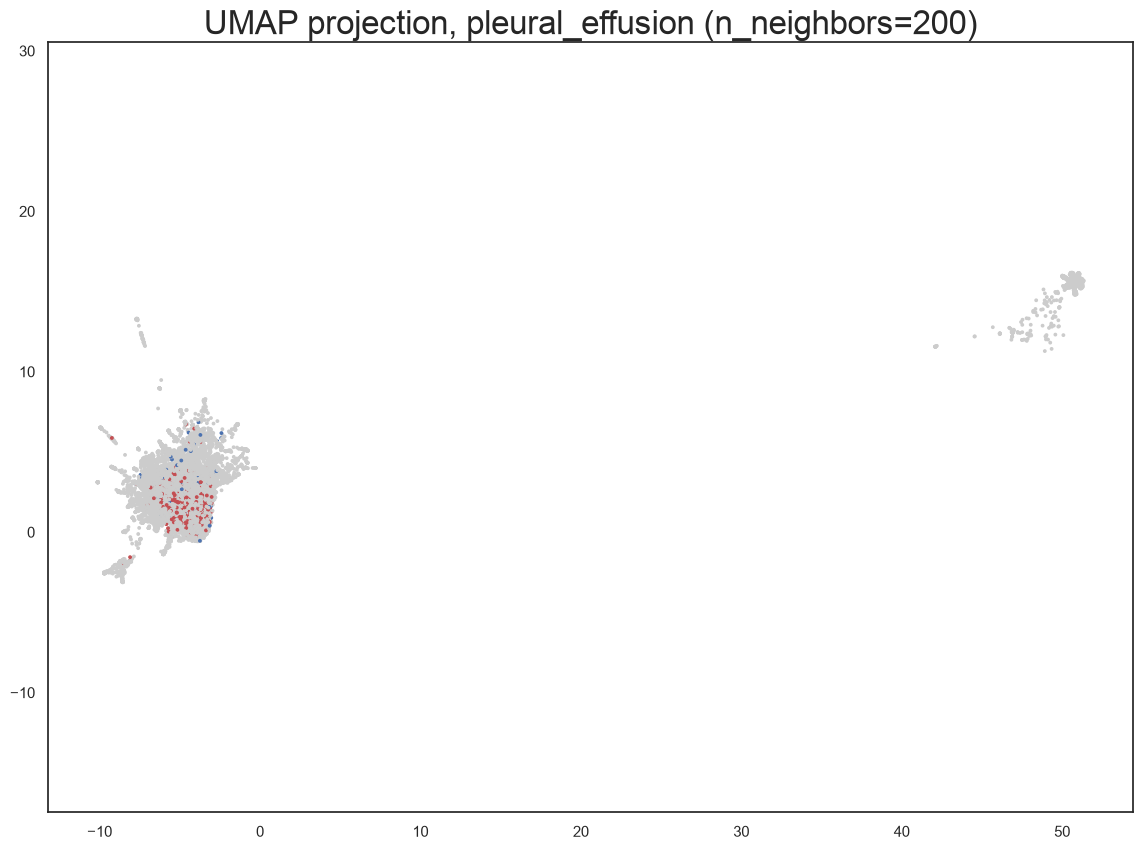

In [8]:
n_neighbours = 200
plot_labels("edema", n_neighbours)
plot_labels("pleural_effusion", n_neighbours)
plt.show()